In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("machine_downtime.csv")

In [3]:
print("Shape Dataset :", df.shape)

df.head(10)

Shape Dataset : (520, 9)


,ID_Kejadian,Tanggal_Kejadian,ID_Mesin,Usia_Mesin_Tahun,Penyebab_Downtime,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Shift_Kejadian,Biaya_Perbaikan_Ribu_Rupiah
0,DT0001,2025-09-03,M08,10.2,Kerusakan Elektrikal,70.5,98.2,Malam,NaN
1,DT0002,2025-11-11,M10,6.4,Kerusakan Mekanis,57.3,77.6,Malam,1149.0
2,DT0003,2025-09-21,M05,7.2,Kerusakan Mekanis,59.9,43.4,Pagi,820.0
3,DT0004,2025-08-23,M06,12.9,Kerusakan Mekanis,79.8,69.8,Siang,1757.0
4,DT0005,2026-01-14,M07,8.5,Kerusakan Mekanis,64.4,100.0,Pagi,787.0
5,DT0006,2025-10-03,M07,8.6,Kerusakan Mekanis,64.8,67.4,Malam,944.0
6,DT0007,2025-12-25,M06,12.9,Kerusakan Mekanis,79.9,100.0,Pagi,NaN
7,DT0008,2025-12-12,M04,11.3,Kerusakan Mekanis,74.3,87.4,Malam,1285.0
8,DT0009,2025-08-27,M09,6.1,Kekurangan Bahan Baku,56.0,65.9,Pagi,909.0
9,DT0010,2025-09-04,M08,10.7,Pergantian Alat (Tooling Change),72.1,55.8,Malam,1828.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Kejadian                  520 non-null    str    
 1   Tanggal_Kejadian             520 non-null    str    
 2   ID_Mesin                     520 non-null    str    
 3   Usia_Mesin_Tahun             520 non-null    float64
 4   Penyebab_Downtime            520 non-null    str    
 5   Durasi_Downtime_Menit        520 non-null    float64
 6   Beban_Kerja_Harian_Persen    520 non-null    float64
 7   Shift_Kejadian               520 non-null    str    
 8   Biaya_Perbaikan_Ribu_Rupiah  427 non-null    float64
dtypes: float64(4), str(5)
memory usage: 36.7 KB


In [6]:
df.dtypes

ID_Kejadian                        str
Tanggal_Kejadian                   str
ID_Mesin                           str
Usia_Mesin_Tahun               float64
Penyebab_Downtime                  str
Durasi_Downtime_Menit          float64
Beban_Kerja_Harian_Persen      float64
Shift_Kejadian                     str
Biaya_Perbaikan_Ribu_Rupiah    float64
dtype: object

In [7]:
df.isnull().sum()

ID_Kejadian                     0
Tanggal_Kejadian                0
ID_Mesin                        0
Usia_Mesin_Tahun                0
Penyebab_Downtime               0
Durasi_Downtime_Menit           0
Beban_Kerja_Harian_Persen       0
Shift_Kejadian                  0
Biaya_Perbaikan_Ribu_Rupiah    93
dtype: int64

In [8]:
median_biaya = df["Biaya_Perbaikan_Ribu_Rupiah"].median()

df["Biaya_Perbaikan_Ribu_Rupiah"] = df[
    "Biaya_Perbaikan_Ribu_Rupiah"
].fillna(median_biaya)

In [9]:
df[df["Usia_Mesin_Tahun"] < 0]

,ID_Kejadian,Tanggal_Kejadian,ID_Mesin,Usia_Mesin_Tahun,Penyebab_Downtime,Durasi_Downtime_Menit,Beban_Kerja_Harian_Persen,Shift_Kejadian,Biaya_Perbaikan_Ribu_Rupiah
81,DT0082,2025-11-17,M09,-5.9,Kerusakan Mekanis,55.2,77.5,Malam,1048.0
110,DT0111,2025-10-01,M05,-6.9,Kerusakan Elektrikal,59.0,63.8,Malam,934.0
129,DT0130,2025-10-08,M09,-6.2,Kesalahan Operator,56.4,74.6,Pagi,557.0
165,DT0166,2025-09-25,M01,-6.5,Kekurangan Bahan Baku,57.6,73.4,Malam,991.0
252,DT0253,2025-12-13,M03,-3.3,Kerusakan Mekanis,46.4,61.4,Pagi,1048.0
294,DT0295,2025-08-19,M03,-3.3,Kerusakan Mekanis,46.3,81.3,Siang,791.0
296,DT0297,2025-08-21,M05,-6.8,Kesalahan Operator,58.5,88.4,Siang,1364.0
309,DT0310,2025-12-26,M03,-2.3,Kerusakan Elektrikal,42.8,92.0,Malam,694.0
335,DT0336,2025-11-17,M05,-6.6,Kerusakan Mekanis,57.8,54.2,Pagi,385.0
409,DT0410,2025-08-17,M03,-2.8,Kerusakan Mekanis,44.5,75.6,Siang,1075.0


In [10]:
(df["Usia_Mesin_Tahun"] < 0).sum()

np.int64(13)

In [11]:
#menangani nilai negatif
df["Usia_Mesin_Tahun"] = df["Usia_Mesin_Tahun"].abs()

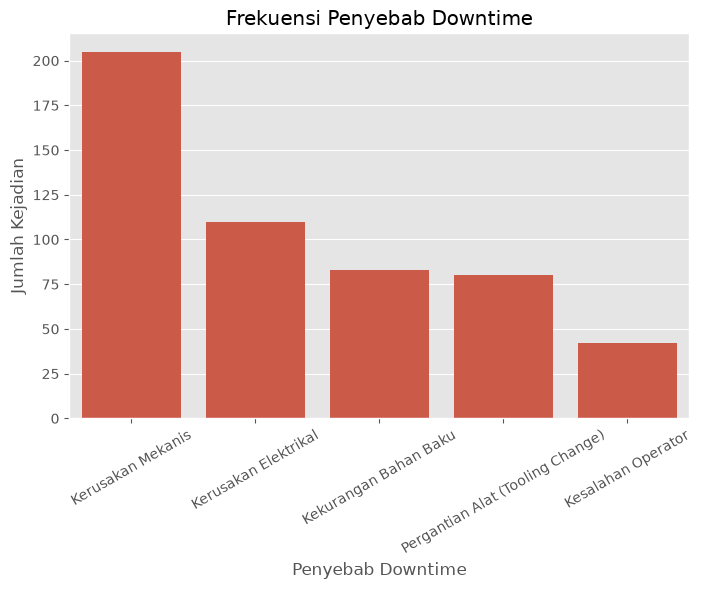

In [12]:
#visualisasi 1
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Penyebab_Downtime",
    order=df["Penyebab_Downtime"].value_counts().index
)

plt.xticks(rotation=30)
plt.title("Frekuensi Penyebab Downtime")
plt.xlabel("Penyebab Downtime")
plt.ylabel("Jumlah Kejadian")

plt.show()

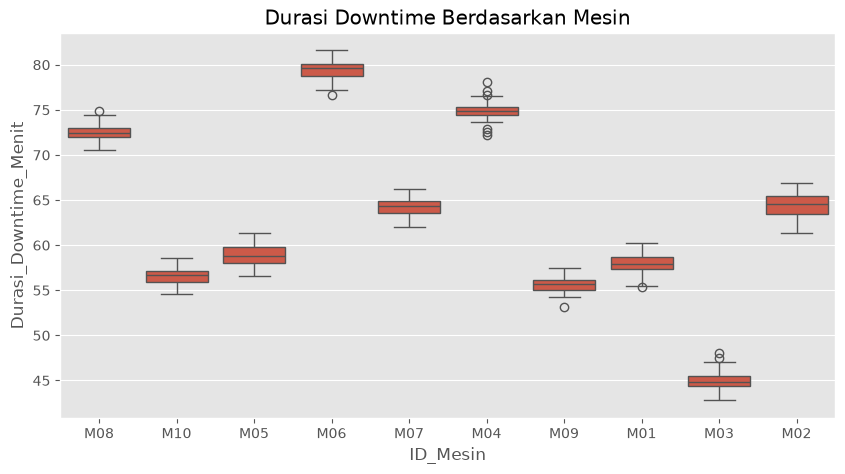

In [13]:
#visualisasi 2

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="ID_Mesin",
    y="Durasi_Downtime_Menit"
)

plt.title("Durasi Downtime Berdasarkan Mesin")

plt.show()

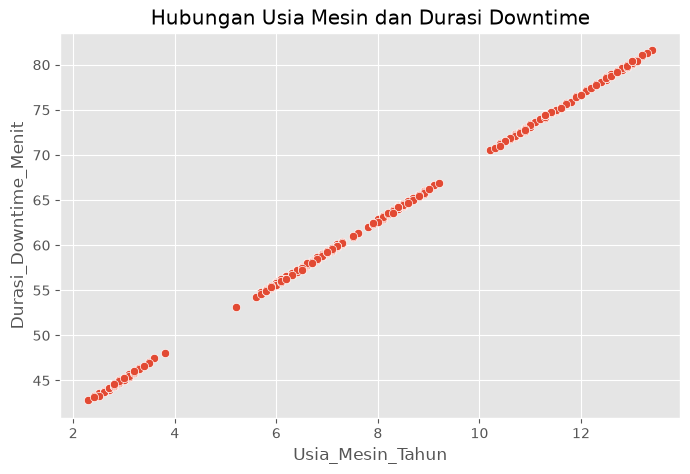

In [14]:
#visualisasi 3
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Usia_Mesin_Tahun",
    y="Durasi_Downtime_Menit"
)

plt.title("Hubungan Usia Mesin dan Durasi Downtime")

plt.show()

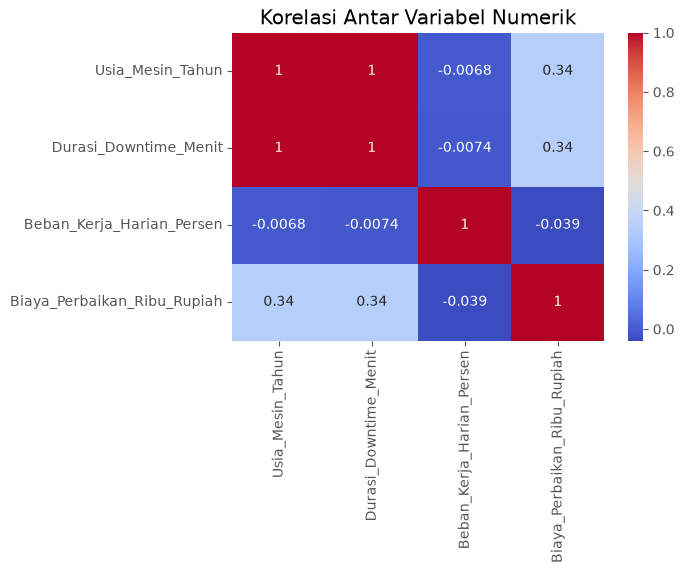

In [15]:
#visualisasi 4
plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Korelasi Antar Variabel Numerik")

plt.show()